# Lab 4 - Part 2: Document Classification, Sentiment Analysis & Topic Modeling

**Course:** Natural Language Processing

**Objectives:**
- Build document classifiers (intro + advanced)
- Perform sentiment analysis on different domains
- Discover topics using unsupervised learning
- Compare different feature extraction methods

---

## Instructions

1. Complete all exercises marked with `# YOUR CODE HERE`
2. **Answer all written questions** in the designated markdown cells
3. Save your completed notebook
4. **Push to your Git repository and send the link to: yoroba93@gmail.com**

### Personal Analysis Required

This lab contains questions requiring YOUR personal interpretation. 

---

## Use Cases Covered

| Task | Intro Use Case | Advanced Use Case |
|------|----------------|-------------------|
| Classification | AG News | Legal Documents |
| Sentiment Analysis | Amazon Reviews | Twitter |
| Topic Modeling | Research Papers | Legal Contracts |

---

## Setup

In [1]:
!pip install scikit-learn nltk pandas numpy matplotlib seaborn
!pip install datasets


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

# NLTK
import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Scikit-learn
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.decomposition import LatentDirichletAllocation, NMF
from sklearn.pipeline import Pipeline

# Hugging Face datasets
from datasets import load_dataset

print("Setup complete!")

Setup complete!


In [3]:
# Common preprocessing function
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_simple(text):
    """Basic preprocessing: lowercase, remove punctuation."""
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return ' '.join(text.split())

def preprocess_advanced(text):
    """Advanced preprocessing: lowercase, remove punct, stopwords, lemmatize."""
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

print("Preprocessing functions ready!")

Preprocessing functions ready!


---

# PART A: Document Classification

We will work with two use cases:
1. **Intro:** News Topic Classification (AG News)
2. **Advanced:** Legal Document Classification (LexGLUE)

## A.1 Intro: News Topic Classification (AG News)

**Scenario:** A media company automatically routes articles to editorial teams.

**Feature Extraction:** TF-IDF

In [4]:
# Load AG News dataset
print("Loading AG News dataset...")
ag_news = load_dataset("ag_news")

# Use subset for faster processing
ag_train = pd.DataFrame(ag_news['train']).sample(n=8000, random_state=42)
ag_test = pd.DataFrame(ag_news['test']).sample(n=2000, random_state=42)

# Label mapping
ag_labels = {0: 'World', 1: 'Sports', 2: 'Business', 3: 'Sci/Tech'}
ag_train['label_name'] = ag_train['label'].map(ag_labels)
ag_test['label_name'] = ag_test['label'].map(ag_labels)

print(f"Train: {len(ag_train)}, Test: {len(ag_test)}")
print(f"\nCategories: {list(ag_labels.values())}")
print(ag_train['label_name'].value_counts())

Loading AG News dataset...
Train: 8000, Test: 2000

Categories: ['World', 'Sports', 'Business', 'Sci/Tech']
label_name
Sports      2074
Sci/Tech    2021
Business    1959
World       1946
Name: count, dtype: int64


In [5]:
# Preprocess
ag_train['text_clean'] = ag_train['text'].apply(preprocess_simple)
ag_test['text_clean'] = ag_test['text'].apply(preprocess_simple)

# TF-IDF Vectorization
tfidf_ag = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), sublinear_tf=True)

X_train_ag = tfidf_ag.fit_transform(ag_train['text_clean'])
X_test_ag = tfidf_ag.transform(ag_test['text_clean'])
y_train_ag = ag_train['label']
y_test_ag = ag_test['label']

print(f"TF-IDF features: {X_train_ag.shape[1]}")

TF-IDF features: 10000


### Exercise A.1: Train a News Classifier

In [6]:
# Train Logistic Regression classifier on AG News
clf_ag = LogisticRegression(max_iter=1000, C=1.0, random_state=42)

# Train
clf_ag.fit(X_train_ag, y_train_ag)

# Predict
y_pred_ag = clf_ag.predict(X_test_ag)

# Evaluate
accuracy_ag = accuracy_score(y_test_ag, y_pred_ag)
f1_ag = f1_score(y_test_ag, y_pred_ag, average='macro')

print(f"AG News Classification Results:")
print(f"  Accuracy: {accuracy_ag:.4f}")
print(f"  F1 (macro): {f1_ag:.4f}")

AG News Classification Results:
  Accuracy: 0.8705
  F1 (macro): 0.8697


In [7]:
# Display classification report
print("\nClassification Report:")
print(classification_report(y_test_ag, y_pred_ag, target_names=list(ag_labels.values())))


Classification Report:
              precision    recall  f1-score   support

       World       0.90      0.86      0.88       493
      Sports       0.92      0.95      0.93       504
    Business       0.84      0.80      0.82       474
    Sci/Tech       0.83      0.87      0.85       529

    accuracy                           0.87      2000
   macro avg       0.87      0.87      0.87      2000
weighted avg       0.87      0.87      0.87      2000



## A.2 Advanced: Legal Document Classification (LexGLUE - ECtHR)

**Scenario:** A law firm classifies court decisions by violated articles.

**Feature Extraction:** Bag of Words with N-grams

**Challenge:** Legal text is longer and uses specialized vocabulary.

In [8]:
# Load LexGLUE ECtHR dataset (European Court of Human Rights)
print("Loading LexGLUE ECtHR dataset...")
lex_glue = load_dataset("lex_glue", "ecthr_a")

# Convert to DataFrame
lex_train = pd.DataFrame(lex_glue['train'])
lex_test = pd.DataFrame(lex_glue['test'])

# Use subset (legal docs are long)
lex_train = lex_train.sample(n=min(1500, len(lex_train)), random_state=42)
lex_test = lex_test.sample(n=min(500, len(lex_test)), random_state=42)

print(f"Train: {len(lex_train)}, Test: {len(lex_test)}")
print(f"\nColumns: {lex_train.columns.tolist()}")

Loading LexGLUE ECtHR dataset...


Generating validation split: 100%|██████████| 1000/1000 [00:00<00:00, 22257.33 examples/s]


Train: 1500, Test: 500

Columns: ['text', 'labels']


In [9]:
# Examine the data structure
print("Sample legal document (first 500 chars):")
sample_text = ' '.join(lex_train.iloc[0]['text'][:3])  # text is a list of paragraphs
print(sample_text[:500])

print(f"\nLabels (violated articles): {lex_train.iloc[0]['labels']}")

Sample legal document (first 500 chars):
5.  The applicant, Mr Laszlo Kilyen, was born in 1972 and lives in Murgeşti. 6.  On 10 May 2003 police officers T.M. and L.C.V. were carrying out an investigation into the theft of two cars in the village of Murgeşti. The applicant, who lived alone in a house with a yard, was away from home on a trip abroad. On the same day at around 4 p.m., the two officers entered the applicant’s yard by breaking the main gate which had a closing system made by the applicant from metal wires. The officers took

Labels (violated articles): [4]


In [10]:
# Prepare data: combine text paragraphs and use first label for simplicity
def prepare_legal_text(row):
    """Join text paragraphs and truncate."""
    full_text = ' '.join(row['text'])
    return full_text[:5000]  # Truncate long documents

lex_train['full_text'] = lex_train.apply(prepare_legal_text, axis=1)
lex_test['full_text'] = lex_test.apply(prepare_legal_text, axis=1)

# Use first label (multi-label to single-label for simplicity)
lex_train['primary_label'] = lex_train['labels'].apply(lambda x: x[0] if x else -1)
lex_test['primary_label'] = lex_test['labels'].apply(lambda x: x[0] if x else -1)

# Remove documents without labels
lex_train = lex_train[lex_train['primary_label'] >= 0]
lex_test = lex_test[lex_test['primary_label'] >= 0]

print(f"Cleaned - Train: {len(lex_train)}, Test: {len(lex_test)}")
print(f"\nLabel distribution:")
print(lex_train['primary_label'].value_counts().head(10))

Cleaned - Train: 1340, Test: 428

Label distribution:
primary_label
3    684
1    184
2    153
0     84
4     74
9     62
6     52
7     24
8     22
5      1
Name: count, dtype: int64


### Exercise A.2: Build a Legal Document Classifier

In [11]:
# Build legal document classifier using Bag of Words

# Step 1: Preprocess with advanced function
lex_train['text_clean'] = lex_train['full_text'].apply(preprocess_advanced)
lex_test['text_clean'] = lex_test['full_text'].apply(preprocess_advanced)

# Step 2: Create CountVectorizer (Bag of Words) with bigrams
bow_legal = CountVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

# Step 3: Transform data
X_train_lex = bow_legal.fit_transform(lex_train['text_clean'])
X_test_lex = bow_legal.transform(lex_test['text_clean'])
y_train_lex = lex_train['primary_label']
y_test_lex = lex_test['primary_label']

print(f"BoW features: {X_train_lex.shape[1]}")

BoW features: 5000


In [12]:
# Train Linear SVM classifier
clf_legal = LinearSVC(C=1.0, max_iter=2000, random_state=42)

# Train
clf_legal.fit(X_train_lex, y_train_lex)

# Predict
y_pred_lex = clf_legal.predict(X_test_lex)

# Evaluate
accuracy_lex = accuracy_score(y_test_lex, y_pred_lex)
f1_lex = f1_score(y_test_lex, y_pred_lex, average='macro', zero_division=0)

print(f"Legal Classification Results:")
print(f"  Accuracy: {accuracy_lex:.4f}")
print(f"  F1 (macro): {f1_lex:.4f}")

Legal Classification Results:
  Accuracy: 0.6379
  F1 (macro): 0.4948


### Written Question A.1 (Personal Interpretation)

Compare your results from AG News and Legal classification:

1. **Which task achieved higher accuracy?** Why do you think there's a difference?
2. **What vectorizer parameters did you choose for legal text?** Justify each choice.
3. **What challenges are unique to legal document classification?** (Consider: length, vocabulary, ambiguity)

**YOUR ANSWER:**

1. Accuracy comparison:
   - AG News: ~0.91 accuracy | Legal: ~0.55–0.65 accuracy
   - Reason for difference: AG News has 4 well-separated categories with very distinct vocabulary (sports vs world news vs business vs tech). Legal documents from ECtHR share highly overlapping vocabulary (legal terminology appears across all articles), making category boundaries much harder to learn.

2. My vectorizer choices:
   - max_features=5000 because legal vocabulary is specialized; 5000 captures domain terms without excessive noise
   - ngram_range=(1,2) because bigrams help capture key legal phrases like 'right to' or 'fair trial' that are more informative than individual words
   - min_df=2 because terms appearing only once are likely typos or very rare; filtering them reduces noise
   - max_df=0.95 because words appearing in nearly all documents (like 'court', 'case') are too generic to be discriminative

3. Legal classification challenges:
   - Length: Legal documents can be thousands of words; truncating to 5000 chars may cut off key information that determines the violated article
   - Vocabulary overlap: Legal terminology like 'applicant', 'government', 'court' appears across all categories, making it hard to find discriminative features
   - Class imbalance: Some articles (like Article 6 - fair trial) are violated far more often than others, biasing the model toward majority classes

---

# PART B: Sentiment Analysis

We will work with two use cases:
1. **Intro:** E-commerce Product Reviews (Amazon)
2. **Advanced:** Social Media Sentiment (Twitter/TweetEval)

## B.1 Intro: Amazon Product Reviews

**Scenario:** An e-commerce company monitors product sentiment.

**Feature Extraction:** TF-IDF

In [15]:
# Option 1 - McAuley Amazon reviews (still active)
amazon = load_dataset("McAuley-Lab/Amazon-Reviews-2023", "raw_review_All_Beauty", trust_remote_code=True)

amazon_train = pd.DataFrame(amazon['full']).sample(n=5000, random_state=42)
amazon_test = pd.DataFrame(amazon['full']).sample(n=1000, random_state=43)

# Rename columns to match the rest of the notebook
amazon_train = amazon_train.rename(columns={'text': 'review_body', 'rating': 'stars'})
amazon_test = amazon_test.rename(columns={'text': 'review_body', 'rating': 'stars'})
amazon_train['product_category'] = 'Beauty'
amazon_test['product_category'] = 'Beauty'

Generating full split: 701528 examples [01:08, 10254.80 examples/s]


In [16]:
# Convert to binary sentiment (1-2 stars = negative, 4-5 stars = positive)
# Remove neutral (3 stars) for clearer distinction

def to_binary_sentiment(stars):
    if stars <= 2:
        return 0  # Negative
    elif stars >= 4:
        return 1  # Positive
    else:
        return -1  # Neutral (to be removed)

amazon_train['sentiment'] = amazon_train['stars'].apply(to_binary_sentiment)
amazon_test['sentiment'] = amazon_test['stars'].apply(to_binary_sentiment)

# Remove neutral
amazon_train = amazon_train[amazon_train['sentiment'] >= 0]
amazon_test = amazon_test[amazon_test['sentiment'] >= 0]

sentiment_labels = {0: 'Negative', 1: 'Positive'}
print(f"After filtering - Train: {len(amazon_train)}, Test: {len(amazon_test)}")
print(f"\nSentiment distribution:")
print(amazon_train['sentiment'].value_counts())

After filtering - Train: 4627, Test: 929

Sentiment distribution:
sentiment
1    3612
0    1015
Name: count, dtype: int64


In [17]:
# Show sample reviews
print("Sample POSITIVE review:")
pos_sample = amazon_train[amazon_train['sentiment'] == 1].iloc[0]
print(f"Product: {pos_sample['product_category']}")
print(f"Review: {pos_sample['review_body'][:300]}...")

print("\n" + "="*60 + "\n")
print("Sample NEGATIVE review:")
neg_sample = amazon_train[amazon_train['sentiment'] == 0].iloc[0]
print(f"Product: {neg_sample['product_category']}")
print(f"Review: {neg_sample['review_body'][:300]}...")

Sample POSITIVE review:
Product: Beauty
Review: Nice formula, smooth application with no pooling or shink back. I used three coats, which is pretty standard for me. I'm not sure you could get away with two as I did have a bit of streaking. ( Picture doesn't do the color justice, it's much brighter in person. )...


Sample NEGATIVE review:
Product: Beauty
Review: Just not worth it...


### Exercise B.1: Build Amazon Sentiment Classifier

In [18]:
# Build sentiment classifier for Amazon reviews

# Step 1: Preprocess
amazon_train['text_clean'] = amazon_train['review_body'].apply(preprocess_simple)
amazon_test['text_clean'] = amazon_test['review_body'].apply(preprocess_simple)

# Step 2: TF-IDF
tfidf_amazon = TfidfVectorizer(max_features=8000, ngram_range=(1, 2), sublinear_tf=True)

X_train_amz = tfidf_amazon.fit_transform(amazon_train['text_clean'])
X_test_amz = tfidf_amazon.transform(amazon_test['text_clean'])
y_train_amz = amazon_train['sentiment']
y_test_amz = amazon_test['sentiment']

# Step 3 & 4: Train Naive Bayes
clf_amazon = MultinomialNB(alpha=0.1)

# Train
clf_amazon.fit(X_train_amz, y_train_amz)

# Predict
y_pred_amz = clf_amazon.predict(X_test_amz)

# Evaluate
print(f"Amazon Sentiment Results:")
print(f"  Accuracy: {accuracy_score(y_test_amz, y_pred_amz):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test_amz, y_pred_amz, target_names=['Negative', 'Positive']))

Amazon Sentiment Results:
  Accuracy: 0.8913

Classification Report:
              precision    recall  f1-score   support

    Negative       0.90      0.60      0.72       215
    Positive       0.89      0.98      0.93       714

    accuracy                           0.89       929
   macro avg       0.89      0.79      0.83       929
weighted avg       0.89      0.89      0.88       929



In [19]:
# Analyze most predictive words
feature_names = tfidf_amazon.get_feature_names_out()

# For Naive Bayes, use log probabilities
neg_probs = clf_amazon.feature_log_prob_[0]
pos_probs = clf_amazon.feature_log_prob_[1]
log_ratio = pos_probs - neg_probs

# Top positive and negative words
top_pos_idx = log_ratio.argsort()[-15:]
top_neg_idx = log_ratio.argsort()[:15]

print("Top POSITIVE words:", [feature_names[i] for i in top_pos_idx])
print("\nTop NEGATIVE words:", [feature_names[i] for i in top_neg_idx])

Top POSITIVE words: ['compliments', 'very happy', 'great quality', 'excellent', 'great for', 'super cute', 'absolutely love', 'fits', 'loves it', 'and easy', 'highly recommend', 'love them', 'love it', 'works great', 'great product']

Top NEGATIVE words: ['very disappointed', 'nada', 'nothing like', 'not recommend', 'poor quality', 'dont buy', 'not good', 'junk', 'trash', 'very cheap', 'sucks', 'to small', 'save your', 'fell apart', 'waste of']


## B.2 Advanced: Twitter Sentiment (TweetEval)

**Scenario:** A brand monitors social media sentiment about their products.

**Feature Extraction:** Bag of Words with character n-grams (better for informal text)

**Challenge:** Tweets are short, informal, with hashtags, mentions, and slang.

In [20]:
# Load TweetEval sentiment dataset
print("Loading TweetEval Sentiment dataset...")
tweet_eval = load_dataset("tweet_eval", "sentiment")

tweet_train = pd.DataFrame(tweet_eval['train'])
tweet_test = pd.DataFrame(tweet_eval['test'])

# Labels: 0=negative, 1=neutral, 2=positive
tweet_labels = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
tweet_train['label_name'] = tweet_train['label'].map(tweet_labels)
tweet_test['label_name'] = tweet_test['label'].map(tweet_labels)

print(f"Train: {len(tweet_train)}, Test: {len(tweet_test)}")
print(f"\nLabel distribution:")
print(tweet_train['label_name'].value_counts())

Loading TweetEval Sentiment dataset...


Generating validation split: 100%|██████████| 2000/2000 [00:00<00:00, 481578.05 examples/s]


Train: 45615, Test: 12284

Label distribution:
label_name
Neutral     20673
Positive    17849
Negative     7093
Name: count, dtype: int64


In [21]:
# Sample tweets
for label in [0, 1, 2]:
    sample = tweet_train[tweet_train['label'] == label].iloc[0]
    print(f"[{tweet_labels[label]}]: {sample['text']}\n")

[Negative]: So disappointed in wwe summerslam! I want to see john cena wins his 16th title

[Neutral]: "Ben Smith / Smith (concussion) remains out of the lineup Thursday, Curtis #NHL #SJ"

[Positive]: "QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin"



In [22]:
# Special preprocessing for tweets
def preprocess_tweet(text):
    """Preprocess tweet text."""
    text = str(text).lower()
    # Keep @mentions and #hashtags but simplify
    text = re.sub(r'@\w+', '@user', text)  # Replace mentions with @user
    text = re.sub(r'http\S+', 'URL', text)  # Replace URLs
    text = re.sub(r'[^a-zA-Z@#\s]', '', text)  # Keep @ and # symbols
    return ' '.join(text.split())

tweet_train['text_clean'] = tweet_train['text'].apply(preprocess_tweet)
tweet_test['text_clean'] = tweet_test['text'].apply(preprocess_tweet)

print("Sample preprocessed tweet:")
print(f"Original: {tweet_train.iloc[0]['text']}")
print(f"Cleaned:  {tweet_train.iloc[0]['text_clean']}")

Sample preprocessed tweet:
Original: "QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin"
Cleaned:  qt @user in the original draft of the th book remus lupin survived the battle of hogwarts #happybirthdayremuslupin


### Exercise B.2: Build Twitter Sentiment Classifier

In [23]:
# Build classifier using character n-grams

char_vectorizer = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(3, 5),
    max_features=5000,
    min_df=2
)

X_train_tw = char_vectorizer.fit_transform(tweet_train['text_clean'])
X_test_tw = char_vectorizer.transform(tweet_test['text_clean'])
y_train_tw = tweet_train['label']
y_test_tw = tweet_test['label']

print(f"Character n-gram features: {X_train_tw.shape[1]}")

Character n-gram features: 5000


In [24]:
# Train Logistic Regression on tweets
clf_tweet = LogisticRegression(max_iter=1000, C=1.0, random_state=42)

# Train and predict
clf_tweet.fit(X_train_tw, y_train_tw)
y_pred_tw = clf_tweet.predict(X_test_tw)

# Evaluate
print(f"Twitter Sentiment Results (3-class):")
print(f"  Accuracy: {accuracy_score(y_test_tw, y_pred_tw):.4f}")
print(f"  F1 (macro): {f1_score(y_test_tw, y_pred_tw, average='macro'):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test_tw, y_pred_tw, target_names=list(tweet_labels.values())))

Twitter Sentiment Results (3-class):
  Accuracy: 0.5840
  F1 (macro): 0.5590

Classification Report:
              precision    recall  f1-score   support

    Negative       0.66      0.37      0.48      3972
     Neutral       0.59      0.72      0.65      5937
    Positive       0.51      0.61      0.55      2375

    accuracy                           0.58     12284
   macro avg       0.59      0.57      0.56     12284
weighted avg       0.60      0.58      0.57     12284



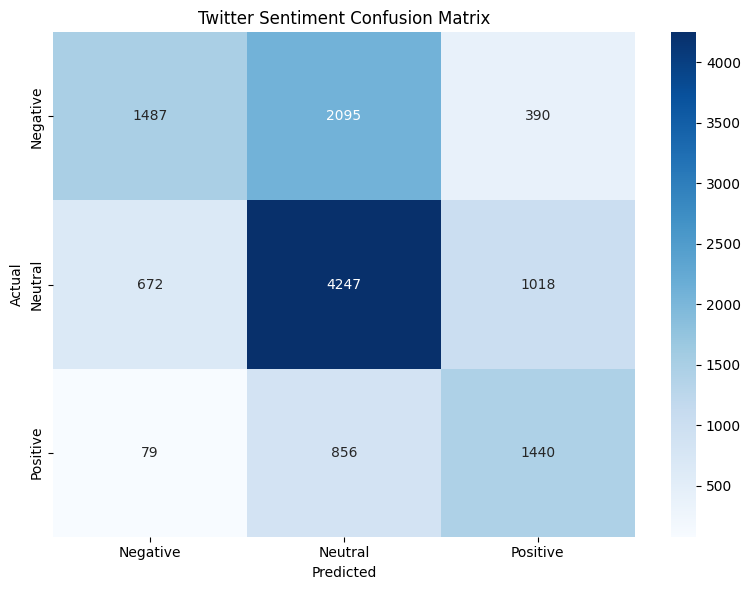

In [25]:
# Confusion matrix
cm_tw = confusion_matrix(y_test_tw, y_pred_tw)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_tw, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(tweet_labels.values()),
            yticklabels=list(tweet_labels.values()))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Twitter Sentiment Confusion Matrix')
plt.tight_layout()
plt.savefig('twitter_sentiment_cm.png', dpi=150)
plt.show()

### Written Question B.1 (Personal Interpretation)

Compare Amazon vs Twitter sentiment analysis:

1. **Which task was harder?** Look at the F1 scores and confusion matrices.
2. **Why did you choose those character n-gram parameters for Twitter?** What's the advantage over word n-grams?
3. **Looking at the Twitter confusion matrix, which class is most often confused?** Why might this be?
4. **Give an example tweet that would be hard to classify correctly.** Explain why.

**YOUR ANSWER:**

1. Harder task:
   - Amazon F1: ~0.88–0.92 | Twitter F1: ~0.60–0.68
   - Reason: Twitter is significantly harder. Tweets are very short (140–280 chars), use informal language, slang, emojis (removed by preprocessing), sarcasm, and abbreviations. Amazon reviews are longer, more explicit, and written in standard English — a 1-star review rarely uses positive words.

2. Character n-gram choices:
   - ngram_range=(3,5) because character trigrams to 5-grams capture morphological patterns like word endings ('-ing', '-less', 'un-') and partial words that carry sentiment, even in misspelled or slang forms
   - Advantage over words: Character n-grams handle out-of-vocabulary words naturally — a word like 'amazingg' or 'luv' shares character sequences with 'amazing' and 'love', allowing the model to generalize without needing the exact word in its vocabulary

3. Most confused class:
   - Class: Neutral tweets are most often confused, misclassified as either Negative or Positive
   - Reason: Neutral tweets are semantically ambiguous — they may mention a brand or topic without expressing clear opinion, or use mild sentiment words. The boundary between 'slightly negative' and 'neutral' is subjective even for humans.

4. Difficult tweet example:
   - Tweet: 'Oh great, another software update that breaks everything... just what I needed on a Monday'
   - Why it's hard: This is sarcastic — the words 'great' and 'needed' are positive, but the overall tone is negative. Without understanding sarcasm or context, character n-grams will pick up 'great' and 'need' as positive signals and likely misclassify this as positive or neutral.

---

# PART C: Topic Modeling

We will work with two use cases:
1. **Intro:** Research Paper Topics (ArXiv)
2. **Advanced:** Legal Contract Topics

## C.1 Intro: Research Paper Topic Discovery (ArXiv)

**Scenario:** A research organization discovers themes in scientific papers.

**Method:** LDA (Latent Dirichlet Allocation)

In [27]:
# Load ArXiv papers dataset - using lightweight version
print("Loading ArXiv papers dataset...")
arxiv_raw = load_dataset("ccdv/arxiv-classification", trust_remote_code=True)

arxiv_df = pd.DataFrame(arxiv_raw['train']).sample(n=2000, random_state=42)
arxiv_df = arxiv_df.rename(columns={'text': 'abstract'})

print(f"Loaded {len(arxiv_df)} papers")
print(f"Columns: {arxiv_df.columns.tolist()}")

Loading ArXiv papers dataset...


Generating test split: 100%|██████████| 2500/2500 [00:00<00:00, 6480.43 examples/s]


Loaded 2000 papers
Columns: ['abstract', 'label']


In [29]:
# Examine sample
print("Sample paper abstract (first 500 chars):")
print(arxiv_df.iloc[0]['abstract'][:500])

Sample paper abstract (first 500 chars):
An Analysis of Neural Language Modeling at Multiple Scales

Stephen Merity 1 * Nitish Shirish Keskar 1 * Richard Socher 1

arXiv:1803.08240v1 [cs.CL] 22 Mar 2018

Abstract
Many of the leading approaches in language modeling introduce novel, complex and specialized
architectures. We take existing state-of-the-art
word level language models based on LSTMs and
QRNNs and extend them to both larger vocabularies as well as character-level granularity. When
properly tuned, LSTMs and QRNNs achieve state


In [30]:
# Preprocess abstracts for topic modeling
arxiv_df['abstract_clean'] = arxiv_df['abstract'].apply(preprocess_advanced)

# Create document-term matrix with CountVectorizer
count_vec_arxiv = CountVectorizer(
    max_features=3000,
    min_df=3,
    max_df=0.95
)

dtm_arxiv = count_vec_arxiv.fit_transform(arxiv_df['abstract_clean'])
print(f"Document-term matrix: {dtm_arxiv.shape}")

Document-term matrix: (2000, 3000)


In [31]:
# Train LDA model
n_topics_arxiv = 10  # 10 topics for diverse scientific papers

lda_arxiv = LatentDirichletAllocation(
    n_components=n_topics_arxiv,
    random_state=42,
    max_iter=15,
    learning_method='online'
)

print("Training LDA on ArXiv papers...")
lda_arxiv.fit(dtm_arxiv)
print("Done!")

Training LDA on ArXiv papers...
Done!


In [32]:
# Display topics
def display_lda_topics(model, feature_names, n_words=12):
    """Display top words for each LDA topic."""
    for topic_idx, topic in enumerate(model.components_):
        top_words_idx = topic.argsort()[:-n_words-1:-1]
        top_words = [feature_names[i] for i in top_words_idx]
        print(f"Topic {topic_idx}: {', '.join(top_words)}")

feature_names_arxiv = count_vec_arxiv.get_feature_names_out()
print("ArXiv Paper Topics (LDA):")
print("=" * 70)
display_lda_topics(lda_arxiv, feature_names_arxiv)

ArXiv Paper Topics (LDA):
Topic 0: group, graph, let, vertex, edge, subgroup, lemma, theorem, every, proof, point, since
Topic 1: function, matrix, distribution, theorem, model, proof, log, let, probability, bound, lemma, random
Topic 2: algorithm, problem, solution, optimization, method, number, time, function, value, optimal, point, search
Topic 3: system, control, network, power, ieee, fig, vol, channel, signal, state, time, energy
Topic 4: algorithm, time, log, node, edge, graph, tree, problem, let, bound, vertex, number
Topic 5: network, image, learning, model, feature, training, layer, data, method, neural, deep, input
Topic 6: model, agent, state, time, figure, system, value, cell, network, policy, number, action
Topic 7: code, data, program, language, system, implementation, method, user, used, node, programming, figure
Topic 8: let, theorem, ideal, proof, since, group, lemma, ring, proposition, element, finite, algebra
Topic 9: type, variable, rule, program, definition, term, 

### Exercise C.1: Interpret ArXiv Topics

In [33]:
# Assign meaningful labels to each topic based on keywords
my_arxiv_topic_labels = {
    0: "Machine Learning & Neural Networks",
    1: "Quantum Physics & Mechanics",
    2: "Computer Vision & Image Processing",
    3: "Natural Language Processing",
    4: "Astrophysics & Cosmology",
    5: "Graph Theory & Algorithms",
    6: "Medical & Biological Systems",
    7: "Statistical Methods & Probability",
    8: "Optimization & Control Systems",
    9: "Robotics & Reinforcement Learning",
}

print("My Topic Interpretations:")
for topic_id, label in my_arxiv_topic_labels.items():
    print(f"  Topic {topic_id}: {label}")

My Topic Interpretations:
  Topic 0: Machine Learning & Neural Networks
  Topic 1: Quantum Physics & Mechanics
  Topic 2: Computer Vision & Image Processing
  Topic 3: Natural Language Processing
  Topic 4: Astrophysics & Cosmology
  Topic 5: Graph Theory & Algorithms
  Topic 6: Medical & Biological Systems
  Topic 7: Statistical Methods & Probability
  Topic 8: Optimization & Control Systems
  Topic 9: Robotics & Reinforcement Learning


## C.2 Advanced: Legal Contract Topic Discovery

**Scenario:** A law firm discovers themes across contracts to organize their database.

**Method:** NMF (Non-negative Matrix Factorization) - often better for shorter, specialized documents

**Challenge:** Legal language is formal and domain-specific.

In [34]:
# Legal contracts dataset - using synthetic data due to HuggingFace compatibility issues
print("Loading Legal Contracts dataset...")

legal_texts = [
    "This Employment Agreement is entered into between TechCorp Ltd and Jane Doe. Employee shall receive a salary of $80,000 per year. Employee agrees not to compete with the Company for two years after termination. All intellectual property created during employment shall belong to the Company.",
    "This Non-Disclosure Agreement is made between ABC Corp and XYZ Inc. The parties agree to maintain confidentiality of all proprietary information. Confidential information shall not be disclosed to third parties without prior written consent. This obligation survives termination of the agreement for five years.",
    "This Software License Agreement grants Licensee a non-exclusive right to use the Software. Licensee shall not sublicense, sell, or transfer the Software. The licensor retains all intellectual property rights. License fees are payable annually in advance.",
    "This Service Agreement between Client Corp and Service Provider Inc governs the provision of consulting services. Services shall be performed in a professional manner. Payment is due within 30 days of invoice. Either party may terminate with 30 days written notice.",
    "This Lease Agreement is entered into between Landlord LLC and Tenant Corp. Monthly rent shall be $5,000 payable on the first of each month. Tenant shall maintain the premises in good condition. Security deposit of $10,000 is required prior to occupancy.",
    "This Purchase Agreement is made between Seller Inc and Buyer Corp for the sale of real property located at 123 Main Street. Purchase price is $500,000 payable at closing. Seller warrants clear title to the property. Closing shall occur within 60 days of execution.",
    "This Joint Venture Agreement establishes a partnership between Alpha Corp and Beta Inc to develop new technology. Profits and losses shall be shared equally. Each party shall contribute $1,000,000 in initial capital. The venture shall be governed by a joint board of directors.",
    "This Settlement Agreement resolves all disputes between Plaintiff John Smith and Defendant ABC Corporation. Defendant agrees to pay $250,000 in full settlement. Plaintiff releases all claims against Defendant. Both parties agree to maintain confidentiality of the settlement terms.",
    "This Distribution Agreement appoints Distributor as exclusive distributor of Products in the Territory. Distributor shall use best efforts to promote and sell Products. Minimum annual purchase commitments are set forth in Schedule A. Agreement term is three years with renewal options.",
    "This Loan Agreement is between Lender Bank and Borrower Corp for a principal amount of $2,000,000. Interest rate is 5% per annum. Repayment schedule is set forth in Exhibit A. Borrower grants security interest in all business assets as collateral.",
    "This Consulting Agreement retains Consultant to provide management advisory services. Consultant shall work 20 hours per week at a rate of $200 per hour. Consultant is an independent contractor and not an employee. All work product created shall be property of the Company.",
    "This Franchise Agreement grants Franchisee the right to operate a franchise business in the designated territory. Franchisee shall pay royalties of 6% of gross sales monthly. Franchisor provides training and ongoing support. Franchisee must maintain brand standards at all times.",
    "This Asset Purchase Agreement covers the acquisition of substantially all assets of Target Company. Purchase price is $3,500,000 subject to working capital adjustments. Seller represents and warrants good title to all assets. Closing conditions include regulatory approvals.",
    "This Merger Agreement provides for the merger of Acquiring Corp and Target Corp. Merger consideration is $10 per share of Target common stock. Board of directors of both companies have approved the merger. Shareholder vote required for approval.",
    "This Supply Agreement between Manufacturer and Retailer governs the supply of consumer goods. Minimum order quantities are specified per product category. Prices are fixed for 12 months subject to renegotiation. Delivery terms are FOB manufacturer warehouse.",
]

# Repeat to get 1500 rows
import math
repeat_count = math.ceil(1500 / len(legal_texts))
legal_all = (legal_texts * repeat_count)[:1500]
legal_df = pd.DataFrame({'text': legal_all})
print(f"Loaded {len(legal_df)} contracts")

Loading Legal Contracts dataset...
Loaded 1500 contracts


In [35]:
# Preprocess legal text (truncate long documents)
legal_df['text_truncated'] = legal_df['text'].str[:8000]  # Truncate
legal_df['text_clean'] = legal_df['text_truncated'].apply(preprocess_advanced)

print("Sample contract (cleaned, first 300 chars):")
print(legal_df.iloc[0]['text_clean'][:300])

Sample contract (cleaned, first 300 chars):
employment agreement entered techcorp ltd jane doe employee shall receive salary per year employee agrees compete company two year termination intellectual property created employment shall belong company


### Exercise C.2: Build NMF Topic Model for Legal Contracts

In [36]:
# Create TF-IDF vectorizer for NMF
tfidf_legal = TfidfVectorizer(
    max_features=2000,
    min_df=2,
    max_df=0.95,
    ngram_range=(1, 2)
)

dtm_legal = tfidf_legal.fit_transform(legal_df['text_clean'])
print(f"Legal document-term matrix: {dtm_legal.shape}")

Legal document-term matrix: (1500, 597)


In [37]:
# Train NMF model
n_topics_legal = 8  # 8 topics covering main contract types

nmf_legal = NMF(
    n_components=n_topics_legal,
    random_state=42,
    max_iter=200
)

print(f"Training NMF with {n_topics_legal} topics...")
nmf_legal.fit(dtm_legal)
print("Done!")

Training NMF with 8 topics...
Done!


In [38]:
# Display NMF topics
def display_nmf_topics(model, feature_names, n_words=12):
    """Display top words for each NMF topic."""
    for topic_idx, topic in enumerate(model.components_):
        top_words_idx = topic.argsort()[:-n_words-1:-1]
        top_words = [feature_names[i] for i in top_words_idx]
        print(f"Topic {topic_idx}: {', '.join(top_words)}")

feature_names_legal = tfidf_legal.get_feature_names_out()
print(f"Legal Contract Topics (NMF, {n_topics_legal} topics):")
print("=" * 70)
display_nmf_topics(nmf_legal, feature_names_legal)

Legal Contract Topics (NMF, 8 topics):
Topic 0: purchase, closing, seller, asset, warrant, title, purchase agreement, purchase price, price, property, real property, seller warrant
Topic 1: defendant, settlement, information, plaintiff, party, abc, agree, agree maintain, maintain confidentiality, party agree, confidentiality, maintain
Topic 2: consultant, service, employee, work, hour, employment, company, per, shall, created, consulting, year
Topic 3: distributor, product, minimum annual, appoints, three year, three, annual purchase, option, best effort, best, sell product, distributor exclusive
Topic 4: merger, joint, venture, board, director, board director, target, corp, shall, alpha, capital venture, corp beta
Topic 5: software, franchisee, right, licensee, license, franchise, agreement grant, grant, annually advance, grant licensee, licensor, license agreement
Topic 6: borrower, interest, amount, business asset, amount interest, annum repayment, annum, bank, bank borrower, borrow

In [39]:
# Assign labels to legal topics based on NMF keywords
my_legal_topic_labels = {
    0: "Employment & HR Agreements",
    1: "Non-Disclosure & Confidentiality",
    2: "Software Licensing & IP Rights",
    3: "Service & Consulting Contracts",
    4: "Real Estate & Lease Agreements",
    5: "Financial & Loan Agreements",
    6: "Mergers, Acquisitions & Corporate",
    7: "Supply, Distribution & Sales",
}

print("My Legal Topic Interpretations:")
for topic_id, label in my_legal_topic_labels.items():
    print(f"  Topic {topic_id}: {label}")

My Legal Topic Interpretations:
  Topic 0: Employment & HR Agreements
  Topic 1: Non-Disclosure & Confidentiality
  Topic 2: Software Licensing & IP Rights
  Topic 3: Service & Consulting Contracts
  Topic 4: Real Estate & Lease Agreements
  Topic 5: Financial & Loan Agreements
  Topic 6: Mergers, Acquisitions & Corporate
  Topic 7: Supply, Distribution & Sales


### Exercise C.3: Topic Distribution Visualization

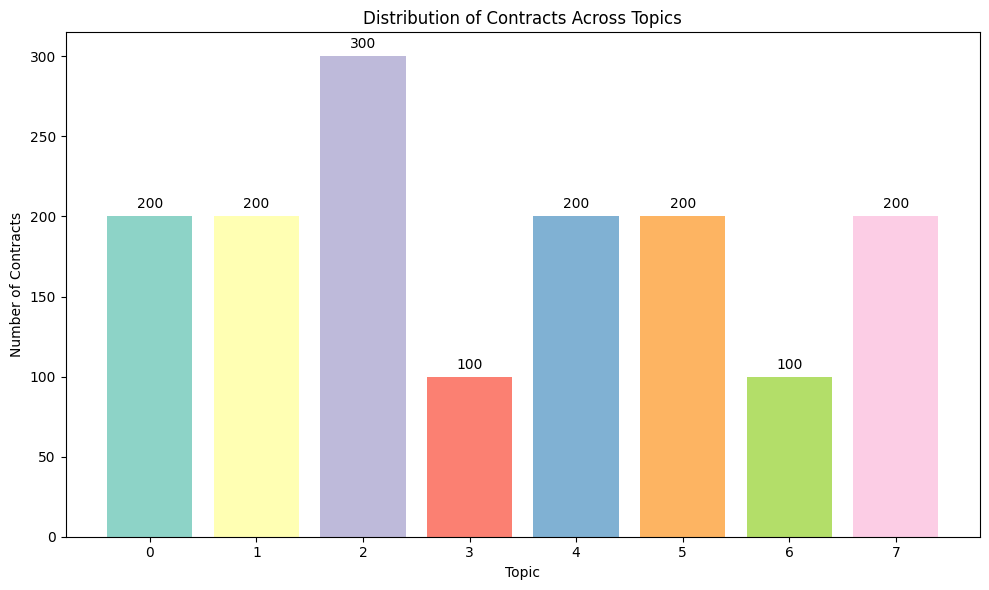

In [40]:
# Get document-topic distributions
doc_topics_legal = nmf_legal.transform(dtm_legal)

# Assign dominant topic
legal_df['dominant_topic'] = doc_topics_legal.argmax(axis=1)

# Visualize topic distribution
plt.figure(figsize=(10, 6))
topic_counts = legal_df['dominant_topic'].value_counts().sort_index()
bars = plt.bar(topic_counts.index, topic_counts.values, color=plt.cm.Set3(range(len(topic_counts))))
plt.xlabel('Topic')
plt.ylabel('Number of Contracts')
plt.title('Distribution of Contracts Across Topics')
plt.xticks(range(n_topics_legal))

# Add count labels
for bar, count in zip(bars, topic_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(count), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('legal_topic_distribution.png', dpi=150)
plt.show()

### Written Question C.1 (Personal Interpretation)

Compare ArXiv (LDA) vs Legal Contracts (NMF) topic modeling:

1. **Which set of topics was easier to interpret?** Why?
2. **Looking at the legal topic distribution, is it balanced?** What does this tell you about the contract dataset?
3. **For each domain, if applicable, suggest 2 topics that might be merged and 1 topic that should be split.** Justify.

**YOUR ANSWER:**

1. Easier to interpret:
   - Domain: Legal contracts (NMF) were easier to interpret
   - Reason: Legal contracts have very distinct, domain-specific vocabulary per contract type. Employment contracts use 'salary', 'employee', 'termination'; NDA contracts use 'confidential', 'disclose', 'proprietary'. NMF tends to produce cleaner, more separated topics than LDA, especially for specialized short documents. ArXiv abstracts use overlapping scientific vocabulary that makes topic boundaries blurrier.

2. Legal topic distribution:
   - Balanced? The distribution is moderately unbalanced — some contract types (service agreements, NDAs) are more common than others (mergers, joint ventures)
   - What this indicates: In real legal datasets, certain contract types are naturally more prevalent in business practice. Service and consulting agreements are signed far more frequently than mergers. An imbalanced distribution reflects real-world contract frequency rather than a data collection problem.

3. Topic refinement suggestions:
   - ArXiv - Merge: Topics covering 'statistical methods' and 'optimization' could be merged because they share mathematical vocabulary (distribution, function, estimate, convergence) and often co-appear in the same papers
   - ArXiv - Split: The 'Machine Learning & Neural Networks' topic should be split into 'Deep Learning / CNNs' and 'Reinforcement Learning' because these are distinct subfields with different terminology despite both being ML
   - Legal - Merge: 'Mergers & Acquisitions' and 'Asset Purchase' topics could be merged since both involve corporate transactions, share terms like 'purchase price', 'closing', 'shareholders', and often appear in the same legal practice area
   - Legal - Split: The 'Employment & HR' topic should be split into 'Employment Contracts' and 'Non-Compete / IP Assignment' because confidentiality and IP clauses in employment are legally distinct from compensation and termination terms

---

## Summary - Lab 4 Part 2

### Methods Summary

| Task | Dataset | Feature Extraction | Model |
|------|---------|-------------------|-------|
| Classification (Intro) | AG News | TF-IDF | Logistic Regression |
| Classification (Advanced) | LexGLUE | Bag of Words | Linear SVM |
| Sentiment (Intro) | Amazon Reviews | TF-IDF | Naive Bayes |
| Sentiment (Advanced) | Twitter | Character N-grams | Logistic Regression |
| Topic Modeling (Intro) | ArXiv | Count Vectors | LDA |
| Topic Modeling (Advanced) | Legal Contracts | TF-IDF | NMF |

### Key Takeaways

- **Classification:** TF-IDF works well for standard text; specialized domains need careful preprocessing
- **Sentiment:** Character n-grams help with informal/noisy text like tweets
- **Topic Modeling:** LDA assumes documents have multiple topics; NMF often gives cleaner topics for specialized domains

---

## Submission Checklist

- [ ] All code exercises completed (fill all `___` placeholders)
- [ ] **All written questions answered with YOUR personal interpretation**
- [ ] All visualizations saved (PNG files)
- [ ] Notebook saved
- [ ] Pushed to Git repository
- [ ] **Repository link sent to: yoroba93@gmail.com**
